In [4]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import exp_pybamm_ver3

In [14]:
# -----------------------------
# 0) Load I/V data
# -----------------------------

def get_vals(T):
    '''
    Run the PyBaMM model and extract the current, voltage, and concentration
    '''
    sol, model, t_eval, param = exp_pybamm_ver3.generate_data()
    t = np.linspace(0, sol['Time [s]'].entries[-1], T)
    I = sol.observe(model.variables['Current [A]'])(t)
    V = sol.observe(model.variables['Terminal voltage [V]'])(t)
    cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.
    return t, V, I, cn

def gen_data_I_c(B, T):
    '''
    B: batch size, T: time steps
    '''
    V = np.zeros((B, 1, T)) # 1 channel
    I = np.zeros((B, 1, T))
    cn = np.zeros((B, 1, T))

    for i in trange(B):
        t, V[i, 0, :], I[i, 0, :], cn[i, 0, :] = get_vals(T)
    return I, cn, t

B = 50
T = 1000
I, cn, t = gen_data_I_c(B, T)


test_size = 0.1
split = int(test_size * B)

I_test = I[:split]
cn_test = cn[:split]
I_train = I[split:]
cn_train = cn[split:]

100%|██████████| 50/50 [00:37<00:00,  1.33it/s]


In [3]:
# -----------------------------
# 1) Scaling
# -----------------------------
# For physics/ODE models you usually want GLOBAL scaling, not a separate mean/std per time index.
scaler_I = StandardScaler()
scaler_V = StandardScaler()

I_train_s = scaler_I.fit_transform(I_train.reshape(-1, 1)).reshape(-1, T)  # global
V_train_s = scaler_V.fit_transform(V_train.reshape(-1, 1)).reshape(-1, T)  # global
I_test_s  = scaler_I.transform(I_test.reshape(-1, 1)).reshape(-1, T)
V_test_s  = scaler_V.transform(V_test.reshape(-1, 1)).reshape(-1, T)

# To keep the ECM solver in PHYSICAL UNITS we will unscale inside the forward, using these constants as torch scalars:
I_mean_t = torch.tensor(float(scaler_I.mean_[0]), dtype=torch.float32)
I_std_t  = torch.tensor(float(scaler_I.scale_[0]), dtype=torch.float32)
V_mean_t = torch.tensor(float(scaler_V.mean_[0]), dtype=torch.float32)
V_std_t  = torch.tensor(float(scaler_V.scale_[0]), dtype=torch.float32)

# To sequences [N, T, 1]
I_train_s = I_train_s[..., None].astype(np.float32)
V_train_s = V_train_s[..., None].astype(np.float32)
I_test_s  = I_test_s[..., None].astype(np.float32)
V_test_s  = V_test_s[..., None].astype(np.float32)

train_dataset = TensorDataset(torch.from_numpy(I_train_s), torch.from_numpy(V_train_s))
loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)


In [4]:
# -----------------------------
# 2) Network
# -----------------------------

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_features=1, out_features=1), # input i_k
            nn.ReLU(),
            nn.Linear(1, 1)  # output V_k
        )

    def forward(self, I_seq_scaled):
        # I_seq_scaled: [B, T, 1] (scaled)
        V_hat = self.head(I_seq_scaled)                     # [B, out_dim]
        return V_hat

In [ ]:
# -----------------------------
# 3) Training loop
# -----------------------------

model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

def training(epochs=50):
    history = {"loss": [], "R0": [], "R1": [], "C1": []}
    for ep in range(epochs):
        model.train()
        last = None

        for I_batch, V_batch in loader:
            # predict parameters
            V_hat = model(I_batch)

            loss = mse(V_hat, V_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            last = float(loss.item())

        history["loss"].append(last)

        print(f'Epoch {ep+1:3d} | loss {last:.6f} |')

    return history

In [7]:
history = training(epochs=20)

Epoch   1 | loss 1.537296 |
Epoch   2 | loss 1.435500 |
Epoch   3 | loss 1.437592 |
Epoch   4 | loss 1.467228 |
Epoch   5 | loss 1.467902 |
Epoch   6 | loss 1.460121 |
Epoch   7 | loss 1.449437 |
Epoch   8 | loss 1.551242 |
Epoch   9 | loss 1.451978 |
Epoch  10 | loss 1.409453 |
Epoch  11 | loss 1.476783 |
Epoch  12 | loss 1.437779 |
Epoch  13 | loss 1.424196 |
Epoch  14 | loss 1.439994 |
Epoch  15 | loss 1.425132 |
Epoch  16 | loss 1.465385 |
Epoch  17 | loss 1.386701 |
Epoch  18 | loss 1.387599 |
Epoch  19 | loss 1.365672 |
Epoch  20 | loss 1.436623 |


Text(0, 0.5, 'Voltage [V]')

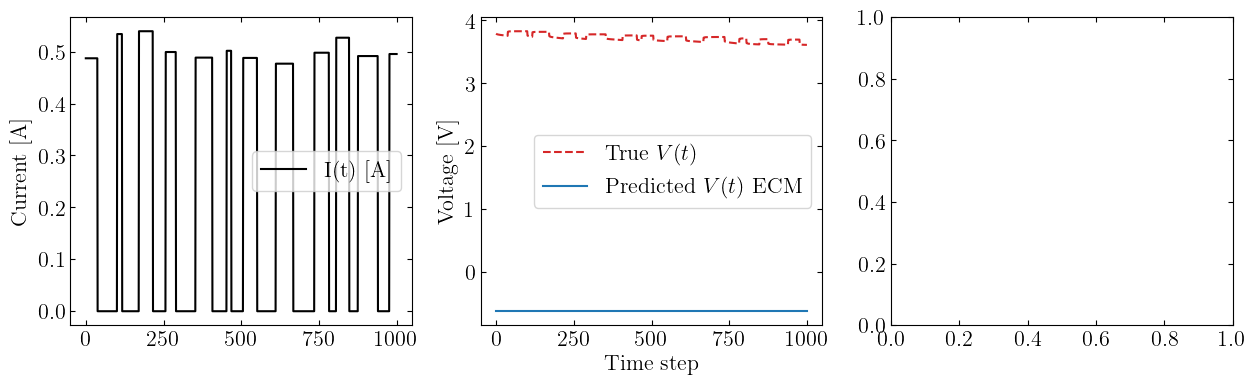

In [ ]:
# -----------------------------
# 4) Test + plot
# -----------------------------
model.eval()
idx = 3

I_seq_s = torch.from_numpy(I_test_s[idx:idx+1])  # [1, T, 1]
V_seq_s = torch.from_numpy(V_test_s[idx:idx+1])  # [1, T, 1]

with torch.no_grad():
    V_hat_phys = model(I_seq_s)

# back to physical for plotting
I_phys = scaler_I.inverse_transform(I_seq_s.squeeze(-1).numpy().reshape(-1, 1)).reshape(1, T)
V_phys = scaler_V.inverse_transform(V_seq_s.squeeze(-1).numpy().reshape(-1, 1)).reshape(1, T)
Vhat_phys_np = V_hat_phys.numpy()


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.plot(I_phys.ravel(), color="black", label="I(t) [A]")
ax2.plot(V_phys.ravel(), color="tab:red", linestyle="dashed", label="True $V(t)$")
ax2.plot(Vhat_phys_np.ravel(), color="tab:blue", label="Predicted $V(t)$ ECM")
ax2.legend()
ax1.legend()
ax2.set_xlabel("Time step")
ax1.set_ylabel("Current [A]")
ax2.set_ylabel("Voltage [V]")

# ax3.plot(history["loss"], label="train loss")
# ax3.set_xlabel("epoch")
# ax3.set_ylabel("MSE (scaled)")
# ax3.legend()
# plt.tight_layout()
# plt.savefig('figs/2_JN_PENN_ECM.pdf')